# Part 1: Face recognition from a database

This notebook follows the Part 1 tasks in Assignment 2. The supplied template is used for opening the HDF5 database and accessing its face arrays and labels.


In [1]:
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt


## 1. Load the face database

The database contains 200 training images, 80 validation images, and 120 test images. Each image is 64 ? 64 pixels; labels identify one of 40 subjects.


In [2]:
data_file = "facedb.hdf5"

with h5.File(data_file, "r") as hf:
    train_images = np.stack([hf["train"][f"face{i}"][:] for i in range(200)])
    valid_images = np.stack([hf["valid"][f"face{i}"][:] for i in range(80)])
    test_images = np.stack([hf["test"][f"face{i}"][:] for i in range(120)])

    train_labels = hf["trainLabels"][:]
    valid_labels = hf["validLabels"][:]
    test_labels = hf["testLabels"][:]

print("Images:", train_images.shape, valid_images.shape, test_images.shape)
print("Labels:", train_labels.shape, valid_labels.shape, test_labels.shape)


Images: (200, 64, 64) (80, 64, 64) (120, 64, 64)
Labels: (200,) (80,) (120,)


## Display the first six faces from each set


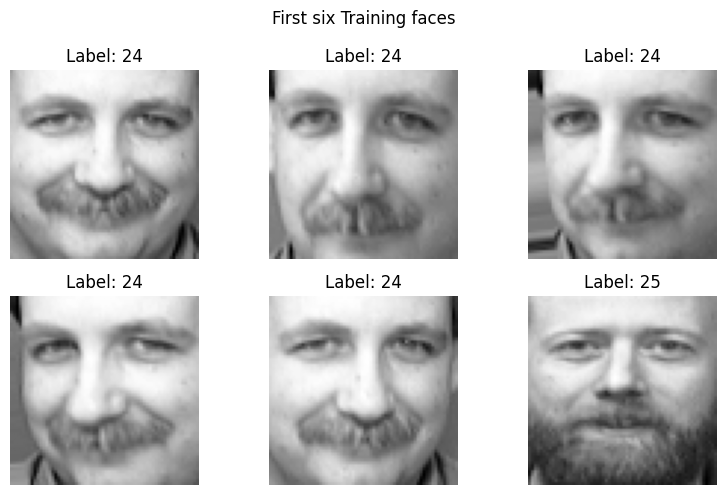

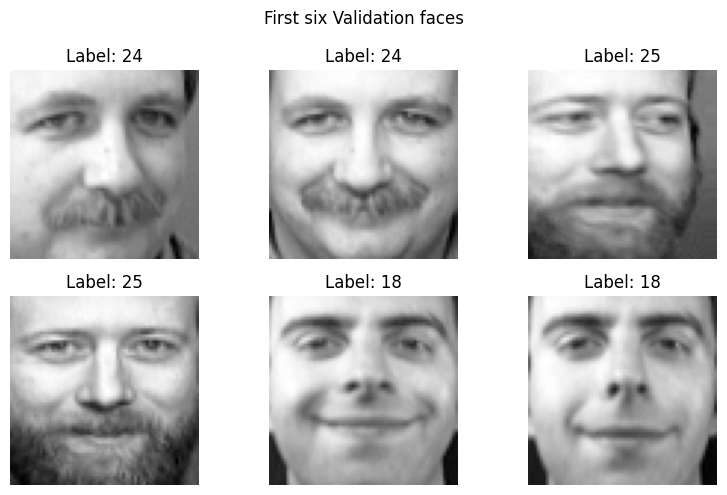

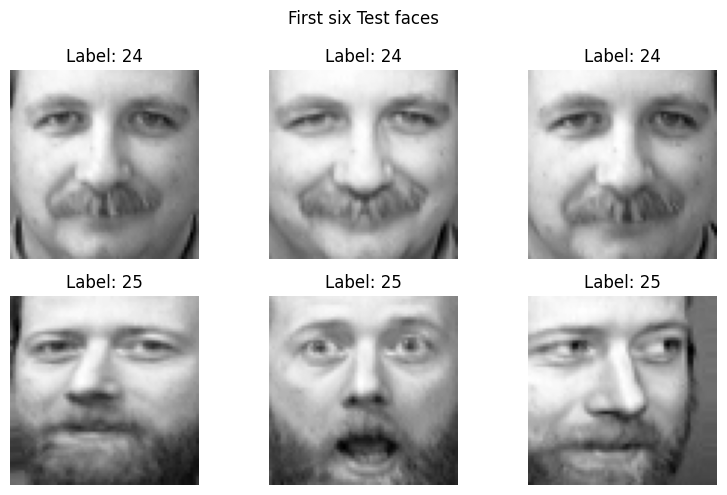

In [3]:
for name, images, labels in [("Training", train_images, train_labels),
                              ("Validation", valid_images, valid_labels),
                              ("Test", test_images, test_labels)]:
    fig, axes = plt.subplots(2, 3, figsize=(8, 5))
    fig.suptitle(f"First six {name} faces")
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], cmap="gray")
        ax.set_title(f"Label: {labels[i]}")
        ax.axis("off")
    fig.tight_layout()
    plt.show()


## Prepare flattened face vectors

Each 64 ? 64 image can be represented as a 4096-element vector. These arrays are the raw pixel features. PCA, required in task 2 onward, has not been applied here.


In [4]:
X_train = train_images.reshape(len(train_images), -1)
X_valid = valid_images.reshape(len(valid_images), -1)
X_test = test_images.reshape(len(test_images), -1)

print("Feature matrices:", X_train.shape, X_valid.shape, X_test.shape)


Feature matrices: (200, 4096) (80, 4096) (120, 4096)
